# Load packages

In [1]:
import scimap as sm
import scanpy as sc

import anndata as ad
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_rel

import seaborn as sns
import matplotlib.pyplot as plt


Running SCIMAP  2.2.11


# Load data

In [2]:
adata = ad.read_h5ad('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/adata_interaction_radius45_imageid.h5ad')

In [4]:
adata.uns['spatial_interaction_radius45_imageid']

,phenotype,neighbour_phenotype,19_02_02A,pvalue_19_02_02A,19_02_01A,pvalue_19_02_01A,T2,pvalue_T2,INF2,pvalue_INF2,19_02_03A,pvalue_19_02_03A,1B,pvalue_1B,2B,pvalue_2B,3B,pvalue_3B,INF1,pvalue_INF1
0,CD206.Macrophages,CD206.Macrophages,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00
1,CD206.Macrophages,CD4.T.cells,0.150976,1.300783e-34,0.190766,0.000000e+00,-0.239333,0.000000e+00,0.372996,5.680282e-202,0.150778,0.000000,0.242094,0.000000e+00,-0.233469,4.536373e-13,-0.088370,2.909132e-04,-0.094998,0.000000e+00
2,CD206.Macrophages,CD68.Macrophages,-0.043375,0.000000e+00,-0.074229,2.465351e-01,-0.149120,1.658592e-186,0.225893,3.652303e-77,0.655337,0.000000,0.085235,1.386576e-02,0.154522,1.745754e-02,-0.126482,0.000000e+00,-0.246316,4.452572e-02
3,CD206.Macrophages,CD8.T.cells,0.070852,0.000000e+00,0.128785,0.000000e+00,-0.048673,5.266268e-46,0.179284,6.138952e-269,0.233650,0.000000,-0.130269,0.000000e+00,-0.167564,0.000000e+00,-0.117421,3.759444e-116,-0.167422,0.000000e+00
4,CD206.Macrophages,Other.Immune,0.097836,5.805508e-147,0.165594,0.000000e+00,-0.059119,2.944598e-97,-0.393672,2.805071e-60,0.196582,0.000000,0.055356,1.321300e-04,0.294446,0.000000e+00,-0.087111,0.000000e+00,-0.096968,1.927466e-106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,VIM+.Stroma,Tumor.GCLC+VIM+,-0.319783,0.000000e+00,0.158298,0.000000e+00,0.072336,3.669308e-240,0.180598,2.882561e-81,0.157854,0.000000,-0.194540,9.235705e-207,-0.078109,8.932934e-10,-0.071216,2.902172e-223,-0.096877,2.366937e-306
165,VIM+.Stroma,Tumor.GCLC+VIM-,-0.042224,0.000000e+00,-0.037861,3.810942e-145,-0.039764,0.000000e+00,-0.111098,1.764734e-13,-0.257130,0.000000,-0.003391,8.097413e-26,-0.001397,4.096793e-61,-0.002015,3.690981e-250,-0.002262,8.976581e-67
166,VIM+.Stroma,Tumor.GCLC-VIM+,-0.039704,8.669859e-03,-0.012495,3.467208e-05,0.011444,5.251644e-34,0.030067,3.241833e-04,-0.000640,0.000002,-0.187695,0.000000e+00,-0.108649,4.695885e-297,-0.140079,0.000000e+00,-0.108224,0.000000e+00
167,VIM+.Stroma,Tumor.GCLC-VIM-,-0.219016,0.000000e+00,-0.407157,0.000000e+00,-0.298764,0.000000e+00,-0.363030,0.000000e+00,-0.639414,0.000000,-0.227382,0.000000e+00,-0.250778,0.000000e+00,-0.120387,0.000000e+00,-0.221877,0.000000e+00


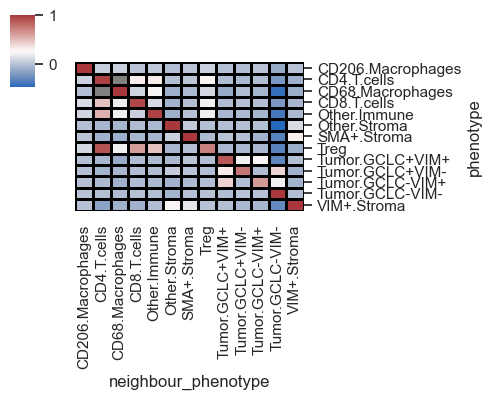

In [5]:
# view the results
sm.pl.spatial_interaction(adata, 
                          spatial_interaction='spatial_interaction_radius45_imageid',
                          linewidths=0.75, linecolor='black', figsize=(5,4))

## Difference between TSI and core

In [ ]:
all_interaction = adata.uns['spatial_interaction_radius45_imageid']
tumor_interaction = all_interaction[all_interaction['phenotype'].isin(['Tumor.GCLC+VIM+','Tumor.GCLC+VIM-','Tumor.GCLC-VIM+','Tumor.GCLC-VIM-'])]
tumor_interaction = tumor_interaction[~tumor_interaction['neighbour_phenotype'].isin(['Tumor.GCLC+VIM+','Tumor.GCLC+VIM-','Tumor.GCLC-VIM+','Tumor.GCLC-VIM-'])]
tumor_interaction

In [13]:
interaction_pairs = tumor_interaction[['phenotype', 'neighbour_phenotype']]
score_cols = [col for col in tumor_interaction.columns if not col.startswith('pvalue') 
              and col not in ['phenotype', 'neighbour_phenotype']]

long_tumor_interaction = tumor_interaction.melt(id_vars=['phenotype', 'neighbour_phenotype'],
                                           value_vars=score_cols,
                                           var_name='sample', value_name='tumor_interaction_score')

In [14]:
long_tumor_interaction

,phenotype,neighbour_phenotype,sample,tumor_interaction_score
0,Tumor.GCLC+VIM+,CD206.Macrophages,19_02_02A,-0.014482
1,Tumor.GCLC+VIM+,CD4.T.cells,19_02_02A,-0.016431
2,Tumor.GCLC+VIM+,CD68.Macrophages,19_02_02A,-0.036367
3,Tumor.GCLC+VIM+,CD8.T.cells,19_02_02A,-0.006508
4,Tumor.GCLC+VIM+,Other.Immune,19_02_02A,-0.010543
...,...,...,...,...
319,Tumor.GCLC-VIM-,Other.Immune,INF1,-0.018184
320,Tumor.GCLC-VIM-,Other.Stroma,INF1,-0.029036
321,Tumor.GCLC-VIM-,SMA+.Stroma,INF1,-0.004272
322,Tumor.GCLC-VIM-,Treg,INF1,-0.004574


In [17]:
test_1 = long_tumor_interaction[long_tumor_interaction['phenotype'] == 'Tumor.GCLC+VIM+'].rename(columns={'tumor_interaction_score':'Tumor.GCLC+VIM+_score'})
test_2 = long_tumor_interaction[long_tumor_interaction['phenotype'] == 'Tumor.GCLC+VIM-'].rename(columns={'tumor_interaction_score':'Tumor.GCLC+VIM-_score'})
test_3 = long_tumor_interaction[long_tumor_interaction['phenotype'] == 'Tumor.GCLC-VIM+'].rename(columns={'tumor_interaction_score':'Tumor.GCLC-VIM+_score'})
test_4 = long_tumor_interaction[long_tumor_interaction['phenotype'] == 'Tumor.GCLC-VIM-'].rename(columns={'tumor_interaction_score':'Tumor.GCLC-VIM-_score'})

In [18]:
merged_interaction = test_1[['neighbour_phenotype','sample','Tumor.GCLC+VIM+_score']].merge(
    test_2[['neighbour_phenotype','sample','Tumor.GCLC+VIM-_score']].merge(
        test_3[['neighbour_phenotype','sample','Tumor.GCLC-VIM+_score']].merge(
            test_4[['neighbour_phenotype','sample','Tumor.GCLC-VIM-_score']],),
    on=['neighbour_phenotype','sample'], how='inner'))

In [21]:
merged_interaction

,neighbour_phenotype,sample,Tumor.GCLC+VIM+_score,Tumor.GCLC+VIM-_score,Tumor.GCLC-VIM+_score,Tumor.GCLC-VIM-_score
0,CD206.Macrophages,19_02_02A,-0.014482,-0.028886,-0.033370,-0.022201
1,CD4.T.cells,19_02_02A,-0.016431,-0.089739,-0.048505,-0.040368
2,CD68.Macrophages,19_02_02A,-0.036367,-0.102251,-0.061736,-0.031930
3,CD8.T.cells,19_02_02A,-0.006508,-0.012469,-0.020630,-0.013628
4,Other.Immune,19_02_02A,-0.010543,-0.054488,-0.045036,-0.061098
...,...,...,...,...,...,...
76,Other.Immune,INF1,-0.019630,-0.027798,-0.065205,-0.018184
77,Other.Stroma,INF1,-0.014614,-0.068953,-0.035987,-0.029036
78,SMA+.Stroma,INF1,0.044161,-0.005054,-0.031447,-0.004272
79,Treg,INF1,-0.012786,-0.002888,-0.035822,-0.004574


In [25]:
# Group by neighbour_phenotype and calculate the mean scores across all samples
pheno_means = merged_interaction.groupby('neighbour_phenotype')[
    ['Tumor.GCLC+VIM+_score', 'Tumor.GCLC+VIM-_score', 
     'Tumor.GCLC-VIM+_score', 'Tumor.GCLC-VIM-_score']
].mean().reset_index()

# Create pairs for comparison
pairs = [
    ('Tumor.GCLC+VIM+', 'Tumor.GCLC+VIM-'),
    ('Tumor.GCLC+VIM+', 'Tumor.GCLC-VIM+'),
    ('Tumor.GCLC+VIM+', 'Tumor.GCLC-VIM-')
]

# Function to calculate log2FC with handling for small values
def calculate_log2fc(mean_A, mean_B):
    epsilon = 1e-6
    log2fc = np.log2((abs(mean_A)+epsilon)/(abs(mean_B)+epsilon))
    log2fc_signed = np.sign(mean_A - mean_B) * log2fc
    return log2fc, log2fc_signed

results = []
for phenotype_A, phenotype_B in pairs:
    for _, row in merged_interaction.groupby('neighbour_phenotype'):
        neighbour = row['neighbour_phenotype'].iloc[0]
        
        # Get scores for each tumor phenotype across all samples
        scores_A = merged_interaction[merged_interaction['neighbour_phenotype'] == neighbour][f'{phenotype_A}_score']
        scores_B = merged_interaction[merged_interaction['neighbour_phenotype'] == neighbour][f'{phenotype_B}_score']
        
        # Calculate mean scores
        mean_A = scores_A.mean()
        mean_B = scores_B.mean()
        
        # Calculate log2FC
        log2fc, log2fc_signed = calculate_log2fc(mean_A, mean_B)
        
        # Perform paired t-test
        # We can use samples as pairs since we have the same samples for both phenotypes
        stat, pval = ttest_rel(scores_A, scores_B)
        
        results.append({
            'phenotype_A': phenotype_A,
            'phenotype_B': phenotype_B,
            'neighbour_phenotype': neighbour,
            'pair': f'{phenotype_A} vs {phenotype_B}',
            f'mean_{phenotype_A}': mean_A,
            f'mean_{phenotype_B}': mean_B,
            'log2FC': log2fc,
            'log2FC_signed': log2fc_signed,
            'p_value': pval,
            'n_samples': len(scores_A)
        })

results_df = pd.DataFrame(results)


In [26]:
results_df

,phenotype_A,phenotype_B,neighbour_phenotype,pair,mean_Tumor.GCLC+VIM+,mean_Tumor.GCLC+VIM-,log2FC,log2FC_signed,p_value,n_samples,mean_Tumor.GCLC-VIM+,mean_Tumor.GCLC-VIM-
0,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,CD206.Macrophages,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.020810,-0.022052,-0.083663,-0.083663,0.863938,9,NaN,NaN
1,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,CD4.T.cells,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.060885,-0.077404,-0.346310,-0.346310,0.263410,9,NaN,NaN
2,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,CD68.Macrophages,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.117939,-0.065362,0.851510,-0.851510,0.365920,9,NaN,NaN
3,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,CD8.T.cells,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.038110,-0.031199,0.288647,-0.288647,0.369864,9,NaN,NaN
4,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,Other.Immune,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.045148,-0.041099,0.135549,-0.135549,0.739939,9,NaN,NaN
5,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,Other.Stroma,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.057306,0.037058,0.628880,-0.628880,0.343884,9,NaN,NaN
6,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,SMA+.Stroma,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.003217,-0.005792,-0.848475,-0.848475,0.938171,9,NaN,NaN
7,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,Treg,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.031416,-0.025723,0.288402,-0.288402,0.437005,9,NaN,NaN
8,Tumor.GCLC+VIM+,Tumor.GCLC+VIM-,VIM+.Stroma,Tumor.GCLC+VIM+ vs Tumor.GCLC+VIM-,-0.024825,-0.084129,-1.760790,-1.760790,0.214815,9,NaN,NaN
9,Tumor.GCLC+VIM+,Tumor.GCLC-VIM+,CD206.Macrophages,Tumor.GCLC+VIM+ vs Tumor.GCLC-VIM+,-0.020810,NaN,0.375301,-0.375301,0.255224,9,-0.016043,NaN


### per celltype pairs

In [27]:
results_df['neighbour_phenotype'].unique()

array(['CD206.Macrophages', 'CD4.T.cells', 'CD68.Macrophages',
       'CD8.T.cells', 'Other.Immune', 'Other.Stroma', 'SMA+.Stroma',
       'Treg', 'VIM+.Stroma'], dtype=object)

In [28]:
celltype_order = ['CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune',
                  'SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma'
                  ]

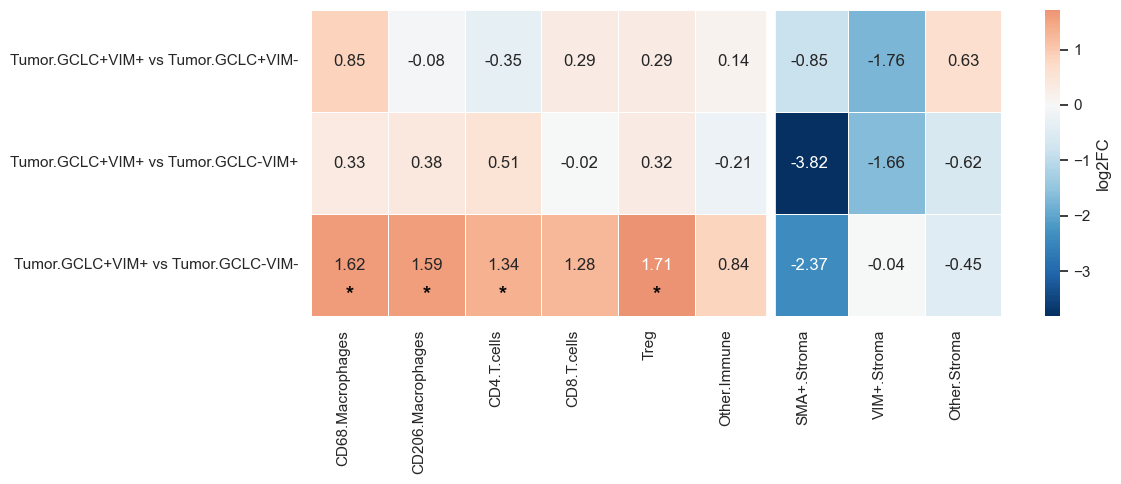

In [31]:

# Create a pivot table for the heatmap
pivot_df = results_df.pivot_table(
    index='pair', 
    columns='neighbour_phenotype', 
    values='log2FC'
)

# Create a pivot table for p-values to mark significance
pval_pivot = results_df.pivot_table(
    index='pair', 
    columns='neighbour_phenotype', 
    values='p_value'
)

# Reorder columns based on celltype_order
ordered_columns = [col for col in celltype_order if col in pivot_df.columns]
pivot_df = pivot_df[ordered_columns]
pval_pivot = pval_pivot[ordered_columns]

# Set up the figure
plt.figure(figsize=(12, 5))

# Create the heatmap
ax = sns.heatmap(pivot_df, cmap="RdBu_r", center=0,
                 annot=True, fmt='.2f', linewidths=0.5,
                 cbar_kws={'label': 'log2FC'})
ax.axvline(6, color='white', linewidth=7)

# Add asterisks for significant p-values
for i, index in enumerate(pivot_df.index):
    for j, column in enumerate(pivot_df.columns):
        if pval_pivot.loc[index, column] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', 
                    horizontalalignment='center', 
                    color='black', fontsize=15, fontweight='bold')

# Set the title and labels
plt.title('', fontsize=16)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)

plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0, ha='right')

plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/Spatial_inderaction_tumor.pdf', bbox_inches='tight', dpi=500)
plt.show()